# 05 — Evaluation

Final evaluation of the SMOTE-balanced XGBoost model: ROC/PR curves, decision-threshold tuning, cross-validated metrics, and a summary comparison table across all model variants produced in this pipeline.

**Input:** `models/xgb_baseline.json`, `models/xgb_smote.json`, `data/train_smote.csv`, `data/test_processed.csv`

**Output:** `outputs/roc_curve.png`, `outputs/pr_curve.png`, `outputs/model_comparison.csv`, `outputs/threshold_tuning.csv`

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

RANDOM_SEED = 42
TARGET_COL = "at_risk"
os.makedirs("outputs", exist_ok=True)

## 1. Load data and models

In [2]:
test_df = pd.read_csv("data/test_processed.csv")
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

models = {}
for name, path in [("baseline", "models/xgb_baseline.json"),
                    ("smote", "models/xgb_smote.json")]:
    if os.path.exists(path):
        m = xgb.XGBClassifier()
        m.load_model(path)
        models[name] = m
    else:
        print(f"Warning: {path} not found, skipping '{name}' model.")

print("Loaded models:", list(models.keys()))

Loaded models: ['baseline', 'smote']


## 2. ROC and Precision-Recall curves

Compares discrimination ability across model variants. ROC-AUC is threshold-independent; the PR curve is especially informative under class imbalance.

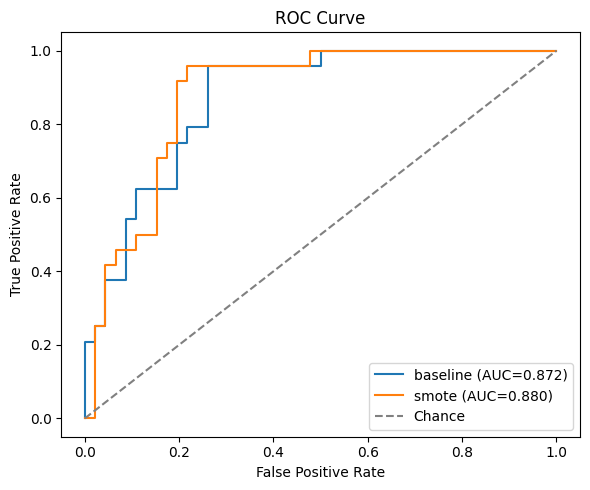

In [3]:
plt.figure(figsize=(6, 5))
for name, m in models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

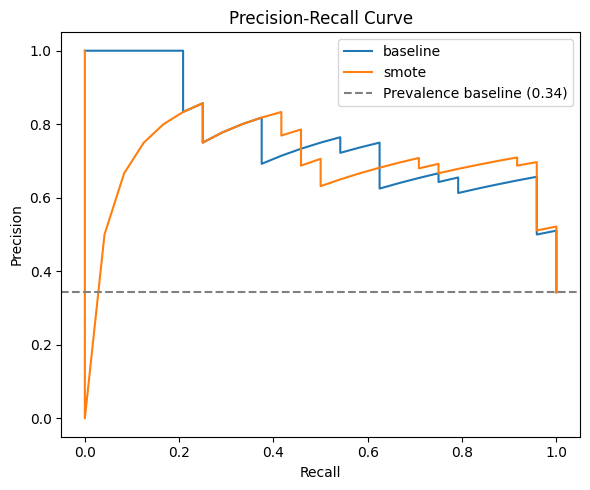

In [4]:
plt.figure(figsize=(6, 5))
for name, m in models.items():
    proba = m.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name)

baseline_rate = y_test.mean()
plt.axhline(baseline_rate, linestyle="--", color="gray",
             label=f"Prevalence baseline ({baseline_rate:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Decision threshold tuning

The default 0.5 probability threshold is rarely optimal under class imbalance. This sweeps thresholds for the SMOTE-balanced model and reports precision/recall/F1 at each, helping select an operating point appropriate for an early-warning context (where recall on the at-risk class is often prioritised).

In [5]:
primary_model_name = "smote" if "smote" in models else list(models.keys())[0]
primary_model = models[primary_model_name]
proba = primary_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    preds = (proba >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "accuracy": accuracy_score(y_test, preds),
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv("outputs/threshold_tuning.csv", index=False)
threshold_df

,threshold,precision,recall,f1,accuracy
0,0.10,0.342857,1.000000,0.510638,0.342857
1,0.15,0.342857,1.000000,0.510638,0.342857
2,0.20,0.342857,1.000000,0.510638,0.342857
3,0.25,0.342857,1.000000,0.510638,0.342857
4,0.30,0.444444,1.000000,0.615385,0.571429
5,0.35,0.510638,1.000000,0.676056,0.671429
6,0.40,0.605263,0.958333,0.741935,0.771429
7,0.45,0.676471,0.958333,0.793103,0.828571
8,0.50,0.680000,0.708333,0.693878,0.785714
9,0.55,0.681818,0.625000,0.652174,0.771429


In [6]:
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"Best F1 threshold for '{primary_model_name}': {best_f1_row['threshold']} "
      f"(F1={best_f1_row['f1']:.3f}, precision={best_f1_row['precision']:.3f}, "
      f"recall={best_f1_row['recall']:.3f})")

Best F1 threshold for 'smote': 0.45 (F1=0.793, precision=0.676, recall=0.958)


## 4. Cross-validated metrics

5-fold stratified cross-validation on the SMOTE-resampled training data gives a more robust estimate of model performance than a single train/test split, especially important given the modest sample size (N=300-400).

In [7]:
if os.path.exists("data/train_smote.csv") and "smote" in models:
    train_smote_df = pd.read_csv("data/train_smote.csv")
    X_train_smote = train_smote_df.drop(columns=[TARGET_COL])
    y_train_smote = train_smote_df[TARGET_COL]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_model = xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_SEED
    )

    for scoring in ["roc_auc", "f1", "precision", "recall", "accuracy"]:
        scores = cross_val_score(cv_model, X_train_smote, y_train_smote, cv=cv, scoring=scoring)
        print(f"{scoring:>10}: mean={scores.mean():.4f} | std={scores.std():.4f} | folds={np.round(scores, 3)}")
else:
    print("data/train_smote.csv or SMOTE model not found - run notebooks 02-03 first.")

   roc_auc: mean=0.8865 | std=0.0115 | folds=[0.879 0.905 0.871 0.89  0.888]
        f1: mean=0.7912 | std=0.0240 | folds=[0.779 0.817 0.805 0.75  0.805]
 precision: mean=0.7765 | std=0.0411 | folds=[0.75  0.853 0.733 0.771 0.775]
    recall: mean=0.8108 | std=0.0541 | folds=[0.811 0.784 0.892 0.73  0.838]
  accuracy: mean=0.7865 | std=0.0232 | folds=[0.77  0.824 0.784 0.757 0.797]


## 5. Final model comparison table

Side-by-side test-set metrics for all model variants produced in this pipeline (baseline vs SMOTE-balanced), plus confusion matrices.

In [8]:
comparison_rows = []
for name, m in models.items():
    preds = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("model")
comparison_df.to_csv("outputs/model_comparison.csv")
comparison_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
baseline,0.771429,0.722222,0.541667,0.619048,0.872283
smote,0.785714,0.680000,0.708333,0.693878,0.879529


In [9]:
for name, m in models.items():
    preds = m.predict(X_test)
    print(f"--- {name}: confusion matrix ---")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, zero_division=0))
    print()

--- baseline: confusion matrix ---
[[41  5]
 [11 13]]
              precision    recall  f1-score   support

           0       0.79      0.89      0.84        46
           1       0.72      0.54      0.62        24

    accuracy                           0.77        70
   macro avg       0.76      0.72      0.73        70
weighted avg       0.77      0.77      0.76        70


--- smote: confusion matrix ---
[[38  8]
 [ 7 17]]
              precision    recall  f1-score   support

           0       0.84      0.83      0.84        46
           1       0.68      0.71      0.69        24

    accuracy                           0.79        70
   macro avg       0.76      0.77      0.76        70
weighted avg       0.79      0.79      0.79        70




## Smoke test checklist
- [ ] ROC and PR curves render and save to `outputs/`
- [ ] Threshold tuning table is produced (`outputs/threshold_tuning.csv`)
- [ ] Cross-validated metrics compute without errors
- [ ] Final comparison table saved (`outputs/model_comparison.csv`)

**End of dummy-data smoke test.** Once HuSSREC ethics clearance is received and real survey data is collected, re-run notebooks 01-05 with `data/dummy_gmt_survey_data.csv` replaced by the real survey export (same column schema).